In [1]:
# importing libraries

In [2]:
# data operation
import pandas as pd 
import numpy as np

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,plot_tree
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier 

# Model Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc

In [3]:
df = pd.read_csv(r"../dataset/cleaned_data.csv")

In [4]:
df

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,No,8,8,4,No
1,97,5.52,5.37,8,No,7,8,0,No
2,109,5.36,5.83,9,No,3,1,1,No
3,122,5.47,5.75,6,Yes,1,6,1,No
4,96,7.91,7.69,7,No,8,10,2,No
...,...,...,...,...,...,...,...,...,...
9746,119,8.41,8.29,4,No,1,8,0,Yes
9747,70,9.25,9.34,7,No,0,7,2,No
9748,89,6.08,6.25,3,Yes,3,9,5,No
9749,107,8.77,8.92,3,No,7,5,1,No


In [5]:
df.columns

['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed','Internship_Experience_Yes',
       'Placement']

['IQ',
 'Prev_Sem_Result',
 'CGPA',
 'Academic_Performance',
 'Extra_Curricular_Score',
 'Communication_Skills',
 'Projects_Completed',
 'Internship_Experience_Yes',
 'Placement']

In [6]:
# Separate features and target
x = df.drop('Placement', axis=1)     # Drop the target column to get input features
y = df['Placement']                  # Target variable

### Encoding

In [7]:
x['Internship_Experience'] = x['Internship_Experience'].map({'Yes':1,'No':0})
y = y.map({'Yes':1,'No':0})

### Spliting the dataset into train test split

In [8]:
# Split into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42,stratify=y)


In [9]:
#Feature scaling (Standardization)
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test) 

## Model No.1
## Logistic Regression

In [10]:
lr = LogisticRegression()

In [11]:
lr.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
lr_predict = lr.predict(x_test)

In [13]:
lr_acc = round(accuracy_score(y_test,lr_predict),4)
print(f'Logictic Regression Accuracy is {lr_acc}')

Logictic Regression Accuracy is 0.8971


In [14]:
print("Classification Report of Logistic Regression Model:\n")
print(classification_report(y_test, lr_predict))

Classification Report of Logistic Regression Model:

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2453
           1       0.72      0.59      0.65       473

    accuracy                           0.90      2926
   macro avg       0.82      0.77      0.80      2926
weighted avg       0.89      0.90      0.89      2926



In [15]:
print("Confusion Matrix\n")
print(confusion_matrix(y_test,lr_predict))

Confusion Matrix

[[2344  109]
 [ 192  281]]


## Model No.2
## Decision Tree Classifier

In [16]:
dtc = DecisionTreeClassifier(max_depth=10, random_state=31)

In [17]:
dtc.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,31
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
dtc_predict = dtc.predict(x_test)

In [19]:
dtc_acc =round( accuracy_score(y_test,dtc_predict),2)
print("Decision Tree classifier score is ",dtc_acc)

Decision Tree classifier score is  1.0


In [20]:
print("Classification Report of Decision Tree Classifier Model :\n")
print(classification_report(y_test, lr_predict))

Classification Report of Decision Tree Classifier Model :

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2453
           1       0.72      0.59      0.65       473

    accuracy                           0.90      2926
   macro avg       0.82      0.77      0.80      2926
weighted avg       0.89      0.90      0.89      2926



In [21]:
print("Confusion Matrix\n")
print(confusion_matrix(y_test,dtc_predict))

Confusion Matrix

[[2453    0]
 [   0  473]]


## Model No.3
## Random Forest Classifier Model

In [22]:
rfc = RandomForestClassifier()

In [23]:
rfc.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
rfc_predict = rfc.predict(x_test)

In [25]:
rfc_acc =round( accuracy_score(y_test,rfc_predict),2)
print(f'Accuracy of Random Forest Classfier is {rfc_acc}')

Accuracy of Random Forest Classfier is 1.0


In [26]:
print("Classification Report of Random Forest Classifier Model :\n")
print(classification_report(y_test, lr_predict))

Classification Report of Random Forest Classifier Model :

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2453
           1       0.72      0.59      0.65       473

    accuracy                           0.90      2926
   macro avg       0.82      0.77      0.80      2926
weighted avg       0.89      0.90      0.89      2926



In [27]:
print("Confusion Matrix\n")
print(confusion_matrix(y_test,rfc_predict))

Confusion Matrix

[[2453    0]
 [   0  473]]


## Model No.4
## XGBoost Classfier

In [28]:
xgboost = XGBClassifier(
    n_estimators=100,   # number of trees
    learning_rate=0.1,  # shrinkage step
    max_depth=4,        # depth of each tree
    random_state=42,
    eval_metric="logloss"
)

In [29]:
xgboost.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [30]:
xgb_predict = xgboost.predict(x_test)
# Evaluate
print("Accuracy:", accuracy_score(y_test, xgb_predict))

Accuracy: 1.0


In [31]:
print("Classification Report of XGBoost Classifier Model:\n")
print(classification_report(y_test, xgb_predict))

Classification Report of XGBoost Classifier Model:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2453
           1       1.00      1.00      1.00       473

    accuracy                           1.00      2926
   macro avg       1.00      1.00      1.00      2926
weighted avg       1.00      1.00      1.00      2926



In [32]:
print("Confusion Matrix\n")
print(confusion_matrix(y_test,xgb_predict))

Confusion Matrix

[[2453    0]
 [   0  473]]


## Model No.5
## K-Nearest Neighbors(KNN) Classfier

In [33]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [34]:
knn_predict = model.predict(x_test)

In [35]:
rfc_acc =round( accuracy_score(y_test,knn_predict),2)
print(f'Accuracy of K-Nearest Neighbors Classifier is {rfc_acc}')

Accuracy of K-Nearest Neighbors Classifier is 0.94


In [36]:
print("Classification Report of K-Nearest Neighbors Classifier Model:\n")
print(classification_report(y_test, knn_predict))

Classification Report of K-Nearest Neighbors Classifier Model:

              precision    recall  f1-score   support

           0       0.95      0.98      0.96      2453
           1       0.87      0.71      0.78       473

    accuracy                           0.94      2926
   macro avg       0.91      0.84      0.87      2926
weighted avg       0.93      0.94      0.93      2926



In [37]:
print("Confusion Matrix\n")
print(confusion_matrix(y_test,knn_predict))

Confusion Matrix

[[2404   49]
 [ 138  335]]


## ROC Curve

In [38]:
test_df = pd.DataFrame({'True': y_test, 'Logistic':lr_predict, 
                        'RandomForest': rfc_predict,
                        'DecisionTree':dtc_predict,
                        'XGBClassifier':xgb_predict,
                        'KNeighborsClassifier':knn_predict
                       })

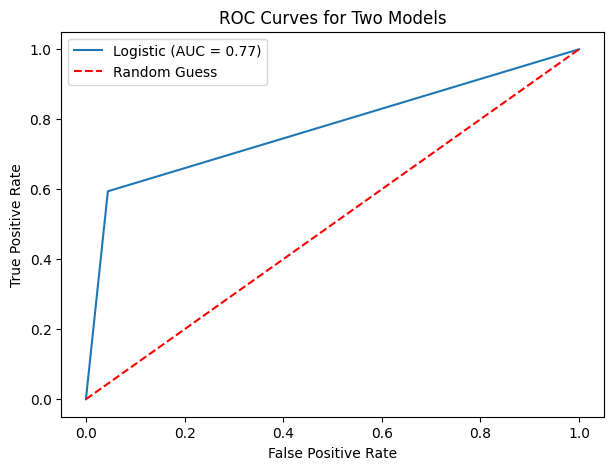

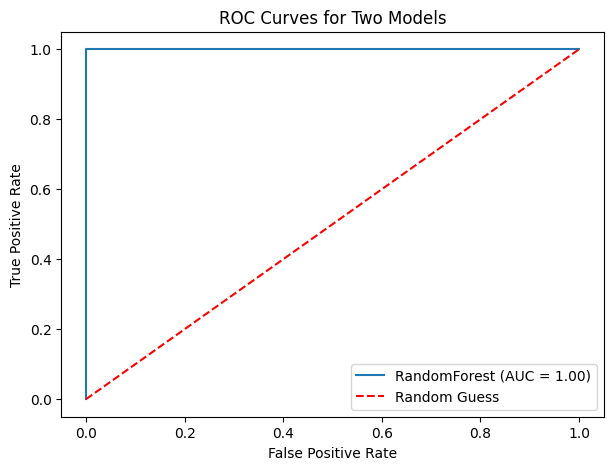

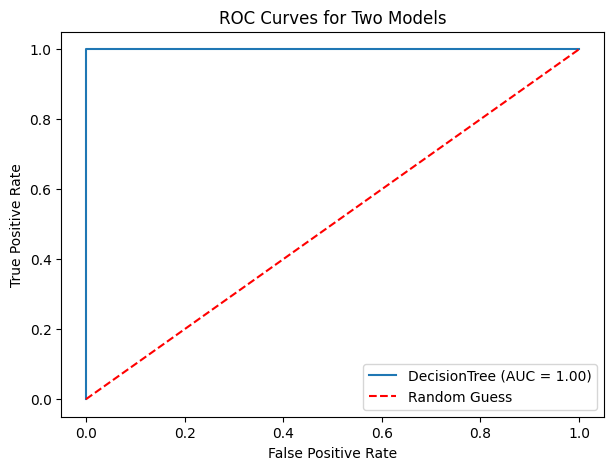

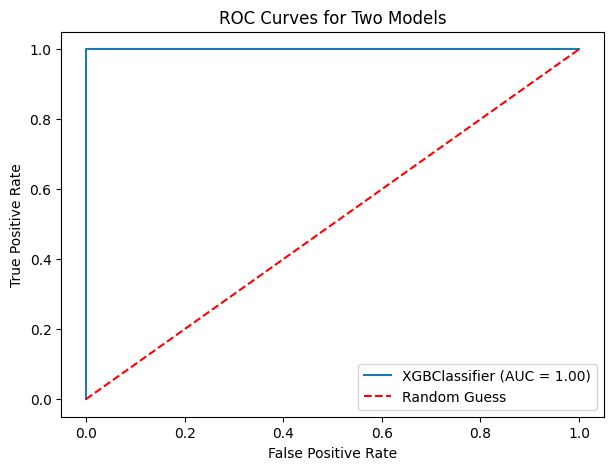

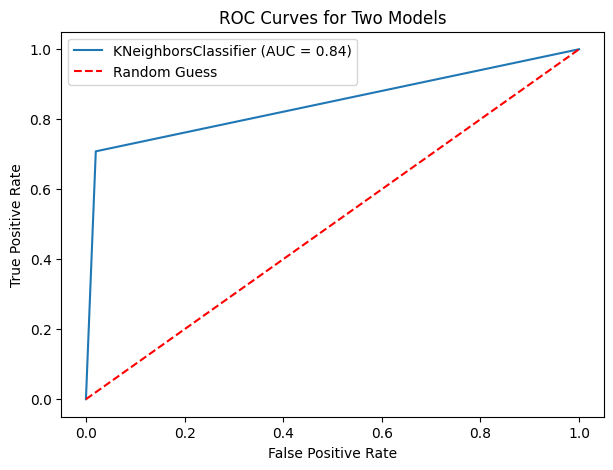

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns


for model in ['Logistic', 'RandomForest','DecisionTree','XGBClassifier','KNeighborsClassifier']:
    plt.figure(figsize=(7, 5))
    fpr, tpr, _ = roc_curve(test_df['True'], test_df[model])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model} (AUC = {roc_auc:.2f})')
    
    plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')
    
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves for Two Models')
    plt.legend()
    plt.savefig(f'../charts/model_related/{model}_ROC_curves.png')
    plt.show()

### Potting a decision tree diagram 

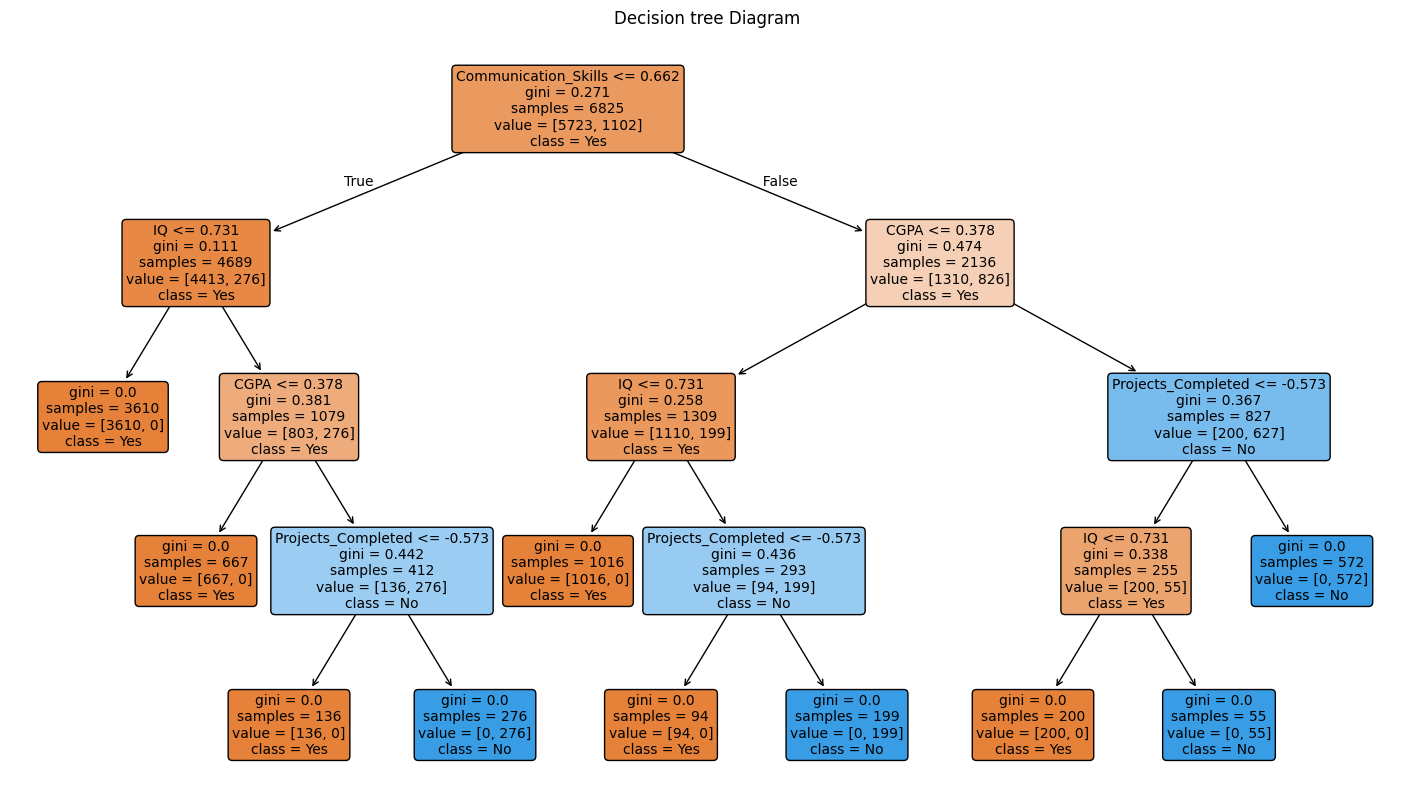

In [40]:
# plot
plt.figure(figsize=(18,10))
plot_tree(dtc,
          feature_names=x.columns.tolist(),
          class_names=["Yes","No"],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Decision tree Diagram")
plt.savefig('../charts/model_related/decision_tree.png')
plt.show()